### Report vendite
Analisi con pandas

In [2]:
import pandas as pd

Ho 4 file. 
* customer
* prodotti
* transazioni
* storico transazioni

1. Quali sono i 10 prodotti più redditizi?

In [3]:
dfcu = pd.read_csv("T02-eCommerce-CustomerMD.csv", delimiter=";")
dfcu.head()

,Customer_ID,Country
0,12346,United Kingdom
1,12347,Iceland
2,12348,Finland
3,12349,Italy
4,12350,Norway


In [4]:
dfcu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer_ID  5856 non-null   int64 
 1   Country      5856 non-null   object
dtypes: int64(1), object(1)
memory usage: 91.6+ KB


In [5]:
dfcu.describe()

,Customer_ID
count,5856.000000
mean,15318.908470
std,1715.858912
min,12346.000000
25%,13834.750000
50%,15322.500000
75%,16808.250000
max,18287.000000


**Prodotti**

In [6]:
dfpr = pd.read_csv("T02-eCommerce-ProductMD.csv", delimiter=",", encoding="latin-1")
dfpr.head()

,StockCode,Description,Category,Subcategory
0,10002R,ROBOT PENCIL SHARPNER,Stationery,Desktop Stationery
1,10109,BENDY COLOUR PENCILS,Stationery,Desktop Stationery
2,10120,DOGGY RUBBER,Stationery,Desktop Stationery
3,10123C,HEARTS WRAPPING TAPE,Stationery,Desktop Stationery
4,10123G,ARMY CAMO WRAPPING TAPE,Stationery,Desktop Stationery


**Transazioni**

In [7]:
dftr = pd.read_excel("T02-eCommerce-TransactionsL3M.xlsx", engine="openpyxl")
dftr.head()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00


In [8]:
dftr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130287 entries, 0 to 130286
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       130287 non-null  object 
 1   StockCode     130287 non-null  object 
 2   Quantity      130287 non-null  int64  
 3   Price         130287 non-null  float64
 4   Customer_ID   130287 non-null  int64  
 5   Invoice_time  130287 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 6.0+ MB


Dalle stat vedo che non ci sono dati nulli. Per verificarlo in modo esplicito...

Come verifico che non ci siano valori mancanti nelle colonne Quantity e Price?


In [27]:
dftr[["Quantity", "Price"]].isna().sum()

Quantity    0
Price       0
dtype: int64

Se ci fossero dati nulli Nan, uso fillna, specificando il valore default da applicare

In [28]:
dftr[["Quantity", "Price"]] = dftr[["Quantity", "Price"]].fillna(0)

Dati storici delle transazioni

In [9]:
dftrh = pd.read_excel("T02-eCommerce-TransactionsHistory.xlsx", engine="openpyxl")
dftrh.head()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,489434,85048,12,6.95,13085,D01/12/17T07:45:00
1,489434,79323P,12,6.75,13085,D01/12/17T07:45:00
2,489434,79323W,12,6.75,13085,D01/12/17T07:45:00
3,489434,22041,48,2.10,13085,D01/12/17T07:45:00
4,489434,21232,24,1.25,13085,D01/12/17T07:45:00


In [10]:
dftrh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545592 entries, 0 to 545591
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       545592 non-null  object 
 1   StockCode     545592 non-null  object 
 2   Quantity      545592 non-null  int64  
 3   Price         545592 non-null  float64
 4   Customer_ID   545592 non-null  int64  
 5   Invoice_time  545592 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 25.0+ MB


unisco le due tabelle con le transazioni

In [11]:
df_tot = pd.concat([dftr, dftrh], ignore_index=True, sort=False)
df_tot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 675879 entries, 0 to 675878
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       675879 non-null  object 
 1   StockCode     675879 non-null  object 
 2   Quantity      675879 non-null  int64  
 3   Price         675879 non-null  float64
 4   Customer_ID   675879 non-null  int64  
 5   Invoice_time  675879 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 30.9+ MB


In [12]:
df_tot.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00


Join delle due tabelle: transaction e customer

In [13]:
customer = dfcu
product = dfpr
transactions = df_tot

transaction2 = transactions.merge(
    customer,
    on="Customer_ID",
    how="left"
)

transaction2.head()


,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom


Per trovare quali sono i 10 prodotti più redditizi:

* calcolare il valore venduto per riga
* raggruppare per prodotto
* sommare

In [14]:
transaction2["total_row"] = transaction2["Quantity"] * transaction2["Price"]
transaction2.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country,total_row
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom,10.0
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom,30.0
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom,25.5
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom,30.0
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom,19.8


totale per prodotto

In [15]:
totale_prodotto = (
    transaction2.groupby("StockCode")["total_row"]
      .sum()
      .reset_index()
)
totale_prodotto.head()

,StockCode,total_row
0,10109,1.68
1,10120,131.88
2,10123C,216.82
3,10123G,90.94
4,10124A,26.04


In [16]:
totale_prodotto = totale_prodotto.sort_values(
    by="total_row",
    ascending=False
)
#limito il df ai soli 10 prodotti
totale_prodotto = totale_prodotto.head(10)
totale_prodotto.head(10)

,StockCode,total_row
1375,22423,265295.62
3169,85123A,240707.67
3153,85099B,166451.16
2988,84879,124354.72
3571,POST,109511.60
2452,47566,102220.93
1128,22086,74510.46
2646,79321,70118.67
1355,22386,66771.74
2483,48138,64128.57


faccio una join con la tabella dei prodotti per avere anche la descrizione

In [17]:
totale_prodotto_desc = totale_prodotto.merge(
    product,
    on="StockCode",
    how="left"
)

totale_prodotto_desc.head(10)

,StockCode,total_row,Description,Category,Subcategory
0,22423,265295.62,REGENCY CAKESTAND 3 TIER,Home,Kitchen
1,85123A,240707.67,WHITE HANGING HEART T-LIGHT HOLDER,Air fragances,Candles
2,85099B,166451.16,JUMBO BAG RED RETROSPOT,Accessories,Bags
3,84879,124354.72,ASSORTED COLOUR BIRD ORNAMENT,Home,Decoration
4,POST,109511.60,POSTAGE,Others,Code
5,47566,102220.93,PARTY BUNTING,Kids,Party
6,22086,74510.46,PAPER CHAIN KIT 50'S CHRISTMAS,Seasonal,Christmas
7,79321,70118.67,CHILLI LIGHTS,Home,Furniture
8,22386,66771.74,JUMBO BAG PINK POLKADOT,Accessories,Bags
9,48138,64128.57,DOORMAT UNION FLAG,Home,Furniture


Elimino colonne inutili 

con drop


In [19]:
df2 = totale_prodotto_desc.drop(columns=["StockCode", "Category", "Subcategory"])
df2

,total_row,Description
0,265295.62,REGENCY CAKESTAND 3 TIER
1,240707.67,WHITE HANGING HEART T-LIGHT HOLDER
2,166451.16,JUMBO BAG RED RETROSPOT
3,124354.72,ASSORTED COLOUR BIRD ORNAMENT
4,109511.60,POSTAGE
5,102220.93,PARTY BUNTING
6,74510.46,PAPER CHAIN KIT 50'S CHRISTMAS
7,70118.67,CHILLI LIGHTS
8,66771.74,JUMBO BAG PINK POLKADOT
9,64128.57,DOORMAT UNION FLAG


rinomino le colonne

In [21]:
df3 = df2.rename(columns={"total_row": "totale", "Description":"prodotto"})
df3


,totale,prodotto
0,265295.62,REGENCY CAKESTAND 3 TIER
1,240707.67,WHITE HANGING HEART T-LIGHT HOLDER
2,166451.16,JUMBO BAG RED RETROSPOT
3,124354.72,ASSORTED COLOUR BIRD ORNAMENT
4,109511.60,POSTAGE
5,102220.93,PARTY BUNTING
6,74510.46,PAPER CHAIN KIT 50'S CHRISTMAS
7,70118.67,CHILLI LIGHTS
8,66771.74,JUMBO BAG PINK POLKADOT
9,64128.57,DOORMAT UNION FLAG


sposto le colonne

In [23]:
df4 = df3[["prodotto", "totale"]]
df4

,prodotto,totale
0,REGENCY CAKESTAND 3 TIER,265295.62
1,WHITE HANGING HEART T-LIGHT HOLDER,240707.67
2,JUMBO BAG RED RETROSPOT,166451.16
3,ASSORTED COLOUR BIRD ORNAMENT,124354.72
4,POSTAGE,109511.60
5,PARTY BUNTING,102220.93
6,PAPER CHAIN KIT 50'S CHRISTMAS,74510.46
7,CHILLI LIGHTS,70118.67
8,JUMBO BAG PINK POLKADOT,66771.74
9,DOORMAT UNION FLAG,64128.57


Un grafico

In [25]:
df4["prodotto"] = df4["prodotto"].str[:15]

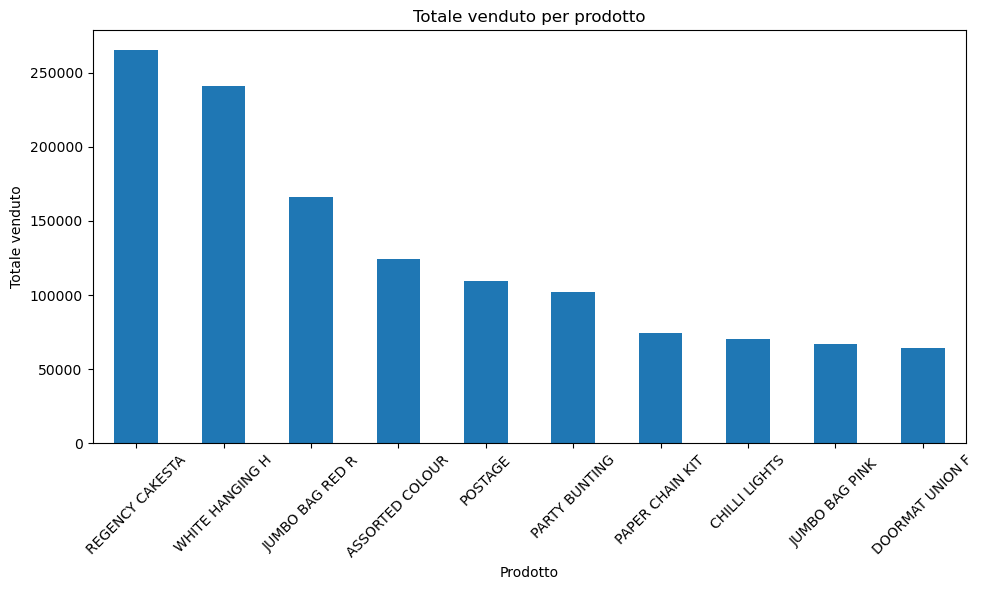

In [26]:
import matplotlib.pyplot as plt

df4.plot(
    x="prodotto",
    y="totale",
    kind="bar",
    figsize=(10, 6),
    legend=False,
    title="Totale venduto per prodotto"
)

plt.xlabel("Prodotto")
plt.ylabel("Totale venduto")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Trovare i totali per ogni sottocategoria

I dati sono in **totale_prodotto_desc**.

In [29]:
totale_prodotto_desc.head(10)

,StockCode,total_row,Description,Category,Subcategory
0,22423,265295.62,REGENCY CAKESTAND 3 TIER,Home,Kitchen
1,85123A,240707.67,WHITE HANGING HEART T-LIGHT HOLDER,Air fragances,Candles
2,85099B,166451.16,JUMBO BAG RED RETROSPOT,Accessories,Bags
3,84879,124354.72,ASSORTED COLOUR BIRD ORNAMENT,Home,Decoration
4,POST,109511.60,POSTAGE,Others,Code
5,47566,102220.93,PARTY BUNTING,Kids,Party
6,22086,74510.46,PAPER CHAIN KIT 50'S CHRISTMAS,Seasonal,Christmas
7,79321,70118.67,CHILLI LIGHTS,Home,Furniture
8,22386,66771.74,JUMBO BAG PINK POLKADOT,Accessories,Bags
9,48138,64128.57,DOORMAT UNION FLAG,Home,Furniture


Decido di escludere la categoria others, ma prima verifico se ci sono subcat nulli

In [32]:
totale_prodotto_desc[["Category"]].isna().sum()

Category    0
dtype: int64

Elimino le voci others. uso lower() per eliminare maiuscole/minuscole

In [33]:
df5 = totale_prodotto_desc[totale_prodotto_desc["Category"].str.lower() != "others"]
df5

,StockCode,total_row,Description,Category,Subcategory
0,22423,265295.62,REGENCY CAKESTAND 3 TIER,Home,Kitchen
1,85123A,240707.67,WHITE HANGING HEART T-LIGHT HOLDER,Air fragances,Candles
2,85099B,166451.16,JUMBO BAG RED RETROSPOT,Accessories,Bags
3,84879,124354.72,ASSORTED COLOUR BIRD ORNAMENT,Home,Decoration
5,47566,102220.93,PARTY BUNTING,Kids,Party
6,22086,74510.46,PAPER CHAIN KIT 50'S CHRISTMAS,Seasonal,Christmas
7,79321,70118.67,CHILLI LIGHTS,Home,Furniture
8,22386,66771.74,JUMBO BAG PINK POLKADOT,Accessories,Bags
9,48138,64128.57,DOORMAT UNION FLAG,Home,Furniture


In [35]:
df6 = (
    df5.groupby("Subcategory", as_index=False)
      .agg(total_sum=("total_row", "sum"))
)
df6

,Subcategory,total_sum
0,Bags,233222.90
1,Candles,240707.67
2,Christmas,74510.46
3,Decoration,124354.72
4,Furniture,134247.24
5,Kitchen,265295.62
6,Party,102220.93


ordino i valori

In [37]:
df7 = df6.sort_values(by="total_sum", ascending=False)
df7 = df7.head(10)
df7

,Subcategory,total_sum
5,Kitchen,265295.62
1,Candles,240707.67
0,Bags,233222.90
4,Furniture,134247.24
3,Decoration,124354.72
6,Party,102220.93
2,Christmas,74510.46


### Trovare i prodotti più venduti in ogni sottocategoria

I dati di vendita sono in **transaction2**

In [38]:
transaction2.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country,total_row
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom,10.0
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom,30.0
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom,25.5
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom,30.0
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom,19.8


mancano però le cat/subcat, allora le unisco con una join sulla tabella product

In [43]:
df8 = transaction2.merge(
    product,
    on="StockCode",
    how="left"
)

df8.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country,total_row,Description,Category,Subcategory
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom,10.0,PINK POLKADOT BOWL,Home,Furniture
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom,30.0,PARTY CONES CANDY ASSORTED,Kids,Party
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom,25.5,REGENCY CAKESTAND 3 TIER,Home,Kitchen
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom,30.0,FAIRY CAKE DESIGN UMBRELLA,Seasonal,Summer
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom,19.8,SET OF 3 REGENCY CAKE TINS,Home,Kitchen


verifico se ci sono categorie nulle

In [44]:
df8[["Category"]].isna().sum()

Category    77
dtype: int64

elimino le voci Nan

In [57]:
df9 = df8.dropna(subset=["Category"])
df9[["Category"]].isna().sum()

Category    0
dtype: int64

estraggo tutte le voci distinte in categorie

In [58]:
categorie = df9["Category"].unique()
categorie

array(['Home', 'Kids', 'Seasonal', 'Stationery', 'Air fragances',
       'Hobbies', 'Accessories', 'Others'], dtype=object)

per ogni categoria devo trovare il prodotto che vende di più. Se dovessi farlo per una sola categoria farei:

1. Filtrare il DataFrame sulla categoria desiderata

2. Calcolare il totale venduto per riga (quantità * prezzo) **(C'è già!!)**

3. Aggregare per prodotto

4. Ordinare per totale decrescente

5. Prendere il primo risultato

In [59]:
# 1. filtriamo la categoria
dfa = df9[df9["Category"] == "Home"]
dfa.head()




,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country,total_row,Description,Category,Subcategory
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom,10.0,PINK POLKADOT BOWL,Home,Furniture
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom,25.5,REGENCY CAKESTAND 3 TIER,Home,Kitchen
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom,19.8,SET OF 3 REGENCY CAKE TINS,Home,Kitchen
10,565083,23263,24,1.25,16187,D01/9/19T09:19:00,United Kingdom,30.0,SET OF 3 WOODEN HEART DECORATIONS,Home,Decoration
11,565084,23309,120,0.42,17306,D01/9/19T09:39:00,United Kingdom,50.4,SET OF 60 I LOVE LONDON CAKE CASES,Home,Kitchen


In [62]:

# 3. sommiamo per prodotto
tp = dfa.groupby("StockCode", as_index=False)["total_row"].sum()
tp.head()

,StockCode,total_row
0,16239,468.40
1,17007B,96.60
2,20671,913.82
3,20672,145.00
4,20673,6.25


In [64]:
# 4. ordiniamo decrescente
tp = tp.sort_values(by="total_row", ascending=False)
# 5. prendiamo il prodotto che vende di più
prod = tp.iloc[0]
print(prod)


StockCode        22423
total_row    265295.62
Name: 526, dtype: object


Avendo le cat in una lista, creo un for

In [69]:

# lista per salvare il top prodotto per ogni categoria
lista = []

for cat in categorie:
    # filtro per categoria e creo una copya del df
    dfa = df9[df9["Category"] == cat].copy()
    
    # somma per prodotto
    tp = dfa.groupby("StockCode", as_index=False)["total_row"].sum()

    # ordina decrescente e prendi il primo prodotto
    tp = tp.sort_values(by="total_row", ascending=False)
    # 5. prendiamo il prodotto che vende di più
    prod = tp.iloc[0]
    
    # salva in dizionario
    lista.append([cat, prod["StockCode"], prod["total_row"]])
    
topdf = pd.DataFrame(data=lista, columns=['Category','StockCode','tot'])
topdf.head()

,Category,StockCode,tot
0,Home,22423,265295.62
1,Kids,47566,102220.93
2,Seasonal,22086,74510.46
3,Stationery,22189,51079.96
4,Air fragances,85123A,240707.67


**TODO/EX**: aggiungere una join per avere i nomi...

**TODO/EX**: raggruppa le vendite per paese e trova i paesi verso cui si vende di più

### Report vendite per mese

dalla tabella df9 (transaction2 in join con la tabella prodotti)... il campo data contiene dati tipo: D01/12/17T07:45:00

In [71]:
df9.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country,total_row,Description,Category,Subcategory
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom,10.0,PINK POLKADOT BOWL,Home,Furniture
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom,30.0,PARTY CONES CANDY ASSORTED,Kids,Party
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom,25.5,REGENCY CAKESTAND 3 TIER,Home,Kitchen
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom,30.0,FAIRY CAKE DESIGN UMBRELLA,Seasonal,Summer
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom,19.8,SET OF 3 REGENCY CAKE TINS,Home,Kitchen


verifico il tipo del campo data

In [77]:
df9.info()

<class 'pandas.core.frame.DataFrame'>
Index: 675802 entries, 0 to 675878
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       675802 non-null  object        
 1   StockCode     675802 non-null  object        
 2   Quantity      675802 non-null  int64         
 3   Price         675802 non-null  float64       
 4   Customer_ID   675802 non-null  int64         
 5   Invoice_time  675802 non-null  datetime64[ns]
 6   Country       672630 non-null  object        
 7   total_row     675802 non-null  float64       
 8   Description   675802 non-null  object        
 9   Category      675802 non-null  object        
 10  Subcategory   675802 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 61.9+ MB


Cerco la data min e la max

In [ ]:

print("Prima data:", df9["Invoice_time"].min())
print("Ultima data:", df9["Invoice_time"].max())


Prima data: 2017-12-01 07:45:00
Ultima data: 2019-11-30 17:42:00


In [ ]:
#copio il df
df10 = df9.copy()
# creo una colonna mese-anno
# .dt accede ai campi della data 
# .to_period("M") Converte un oggetto datetime in un Periodo mensile (Period)
df10["year_month"] = df10["Invoice_time"].dt.to_period("M")


In [79]:
vendite_mensili = (
    df10.groupby("year_month")["total_row"]
      .sum()
      .reset_index()
      .rename(columns={"total_row": "totale_venduto"})
)
vendite_mensili.head()

,year_month,totale_venduto
0,2017-12,592690.950
1,2018-01,465229.352
2,2018-02,424848.866
3,2018-03,539826.461
4,2018-04,479393.562


In [80]:
#ordino i dati
vendite_mensili = vendite_mensili.sort_values("year_month")


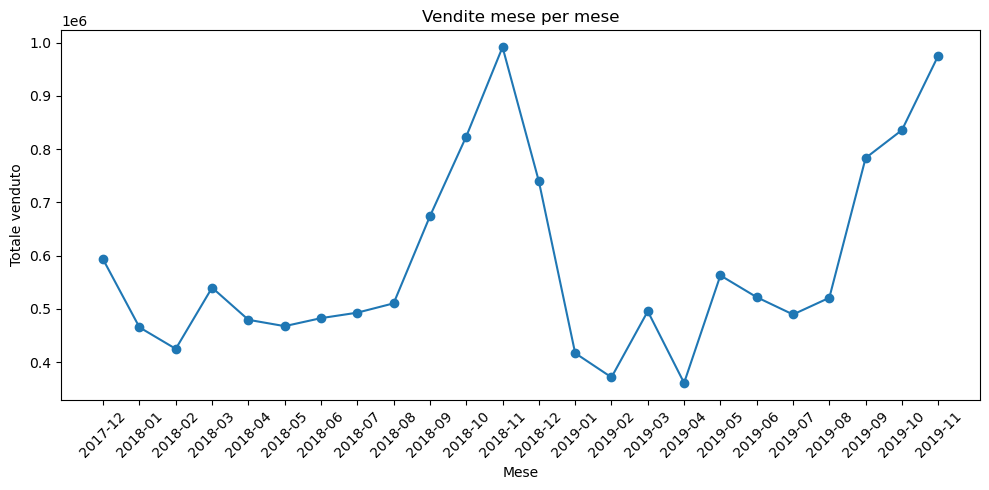

In [81]:
#grafico
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(vendite_mensili["year_month"].astype(str), vendite_mensili["totale_venduto"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Mese")
plt.ylabel("Totale venduto")
plt.title("Vendite mese per mese")
plt.tight_layout()
plt.show()
